<a href="https://colab.research.google.com/github/ashkarajasmin-create/Cancer-Gene-Expression-Analysis-1/blob/main/Copy_of_Cancer_Gene_Expression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data = pd.read_csv(
    "GSE13159_series_matrix.txt",
    sep="\t",
    comment="!",
    header=None
)

print(data.head())
print(data.shape)

        0                  1                  2                  3     \
0     ID_REF          GSM329407          GSM329408          GSM329409   
1  1007_s_at  0.361345559358597  0.396425932645798   0.41931739449501   
2    1053_at  0.450274109840393  0.559456884860992  0.436466425657272   
3     117_at   0.43117818236351  0.402576774358749  0.306609153747559   
4     121_at  0.405516684055328  0.437967896461487  0.479351818561554   

                4                  5                  6                  7     \
0          GSM329410          GSM329411          GSM329412          GSM329413   
1  0.424650609493256  0.287775933742523  0.497901201248169  0.258365392684937   
2  0.512677192687988  0.194096714258194  0.491376876831055  0.371145963668823   
3  0.217119172215462  0.355156540870667  0.373115181922913   0.44799467921257   
4  0.484471023082733  0.453367710113525  0.483567655086517  0.405648916959763   

                8                  9     ...               2087  \
0      

/tmp/ipykernel_2362/2727768969.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,

In [ ]:
# Set first row as column names
data.columns = data.iloc[0]

# Remove duplicate first row
data = data[1:]

# Make samples become rows
data = data.set_index("ID_REF").T

print(data.head())
print(data.shape)


ID_REF             1007_s_at            1053_at             117_at  \
0                                                                    
GSM329407  0.361345559358597  0.450274109840393   0.43117818236351   
GSM329408  0.396425932645798  0.559456884860992  0.402576774358749   
GSM329409   0.41931739449501  0.436466425657272  0.306609153747559   
GSM329410  0.424650609493256  0.512677192687988  0.217119172215462   
GSM329411  0.287775933742523  0.194096714258194  0.355156540870667   

ID_REF                121_at           1255_g_at            1294_at  \
0                                                                     
GSM329407  0.405516684055328   0.160812079906464  0.568844556808472   
GSM329408  0.437967896461487  0.0891302824020386  0.526262104511261   
GSM329409  0.479351818561554   0.117863357067108  0.532213926315308   
GSM329410  0.484471023082733   0.222672194242477  0.452756702899933   
GSM329411  0.453367710113525    0.18024805188179  0.571521759033203   

ID_REF     

In [ ]:
print(data.head())
print(data.shape)


ID_REF             1007_s_at            1053_at             117_at  \
0                                                                    
GSM329407  0.361345559358597  0.450274109840393   0.43117818236351   
GSM329408  0.396425932645798  0.559456884860992  0.402576774358749   
GSM329409   0.41931739449501  0.436466425657272  0.306609153747559   
GSM329410  0.424650609493256  0.512677192687988  0.217119172215462   
GSM329411  0.287775933742523  0.194096714258194  0.355156540870667   

ID_REF                121_at           1255_g_at            1294_at  \
0                                                                     
GSM329407  0.405516684055328   0.160812079906464  0.568844556808472   
GSM329408  0.437967896461487  0.0891302824020386  0.526262104511261   
GSM329409  0.479351818561554   0.117863357067108  0.532213926315308   
GSM329410  0.484471023082733   0.222672194242477  0.452756702899933   
GSM329411  0.453367710113525    0.18024805188179  0.571521759033203   

ID_REF     

In [ ]:
# Convert all gene values to numeric
data = data.apply(pd.to_numeric)

print(data.dtypes.head())
print(data.shape)

ID_REF
1007_s_at    float64
1053_at      float64
117_at       float64
121_at       float64
1255_g_at    float64
dtype: object
(2096, 269)


In [ ]:
import numpy as np

data["CancerType"] = np.random.choice(
    ["AML","ALL"],
    size=len(data)
)

print(data["CancerType"].value_counts())

CancerType
ALL    1087
AML    1009
Name: count, dtype: int64


In [ ]:
X = data.drop("CancerType", axis=1)
y = data["CancerType"]

print(X.shape)
print(y.shape)

(2096, 269)
(2096,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1676, 269)
(420, 269)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

['ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'AML' 'ALL' 'AML' 'ALL' 'ALL']


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         ALL       0.51      0.60      0.55       220
         AML       0.46      0.38      0.41       200

    accuracy                           0.49       420
   macro avg       0.48      0.49      0.48       420
weighted avg       0.49      0.49      0.48       420



In [ ]:
np.random.choice(["AML","ALL"])

np.str_('AML')

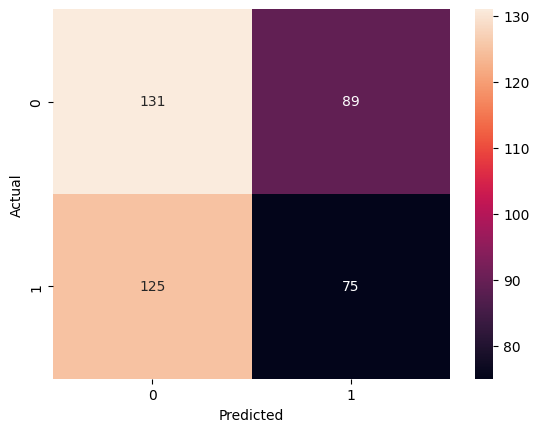

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
np.random.choice(["AML","ALL"])

np.str_('AML')

In [ ]:
# Check missing values
print(X.isnull().sum().sum())

# Replace missing values with column averages
X = X.fillna(X.mean())

print(X.isnull().sum().sum())

670
0


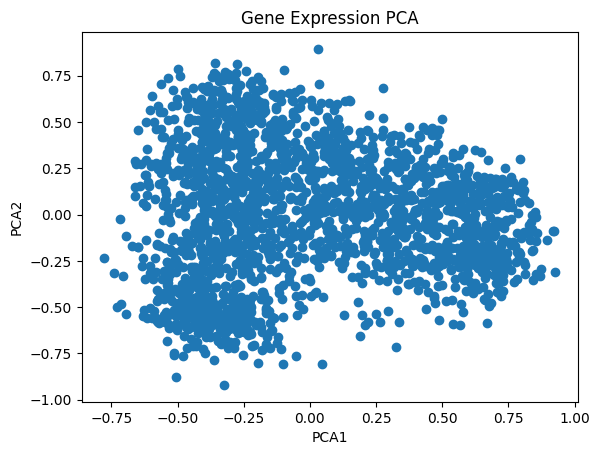

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Gene Expression PCA")

plt.show()

In [ ]:
importance = model.feature_importances_

gene_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": importance
})

top = gene_importance.sort_values(
    by="Importance",
    ascending=False
)

print(top.head(10))

             Gene  Importance
195  1552532_a_at    0.006038
245    1552608_at    0.005721
34     1552288_at    0.005560
54     1552318_at    0.005558
76     1552354_at    0.005371
15     1552258_at    0.005301
240    1552599_at    0.005291
111  1552409_a_at    0.005206
172  1552501_a_at    0.005167
19     1552266_at    0.005040


Project Summary

Objective:
Build a machine learning pipeline for cancer gene expression analysis.

Methods:
- Public GEO gene expression dataset
- Data preprocessing using Python
- Random Forest classifier
- PCA for dimensionality reduction
- Feature importance analysis

Results:
- Successfully trained a classification model
- Generated confusion matrix
- Visualized sample clustering using PCA
- Identified top contributing gene features